# EDA ANALYSIS

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# dataset
df = pd.read_csv(r"F:\Data Analytics\Elevate Labs Internship\Projects\Project_1\Cleaned_Dataset\data.csv")
df.head(1)

,order_id,product_id,user_id,order_date,return_date,product_category,product_price,order_quantity,return_reason,return_status,days_to_return,user_age,user_gender,user_location,payment_method,shipping_method,discount_applied
0,ORD00000000,PROD00000000,USER00000000,2023-08-05,2024-08-26,Clothing,411.59,3,Changed mind,Returned,387.0,58,Male,City54,Debit Card,Next-Day,45.27


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          10000 non-null  object 
 1   product_id        10000 non-null  object 
 2   user_id           10000 non-null  object 
 3   order_date        10000 non-null  object 
 4   return_date       5052 non-null   object 
 5   product_category  10000 non-null  object 
 6   product_price     10000 non-null  float64
 7   order_quantity    10000 non-null  int64  
 8   return_reason     5052 non-null   object 
 9   return_status     10000 non-null  object 
 10  days_to_return    5052 non-null   float64
 11  user_age          10000 non-null  int64  
 12  user_gender       10000 non-null  object 
 13  user_location     10000 non-null  object 
 14  payment_method    10000 non-null  object 
 15  shipping_method   10000 non-null  object 
 16  discount_applied  10000 non-null  float64

,product_price,order_quantity,days_to_return,user_age,discount_applied
count,10000.000000,10000.000000,5052.000000,10000.000000,10000.000000
mean,252.369307,3.006100,243.264054,44.195000,24.992162
std,142.883865,1.406791,172.066819,15.311983,14.363396
min,5.010000,1.000000,0.000000,18.000000,0.000000
25%,128.650000,2.000000,96.000000,31.000000,12.752500
50%,250.445000,3.000000,216.000000,44.000000,24.840000
75%,377.837500,4.000000,366.000000,57.000000,37.605000
max,499.890000,5.000000,726.000000,70.000000,50.000000


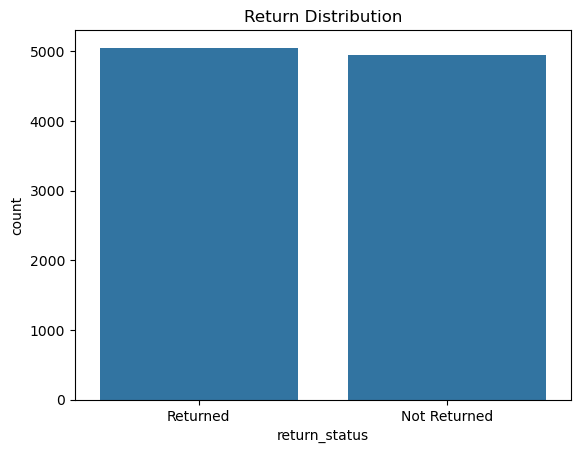

In [3]:
# Overall Return Distribution
sns.countplot(x="return_status", data=df)
plt.title("Return Distribution")
plt.show()

**Outcome** : 
> The graph show that return status have nearly equal counts, around 5,000 items each, but return count is high than not returned.

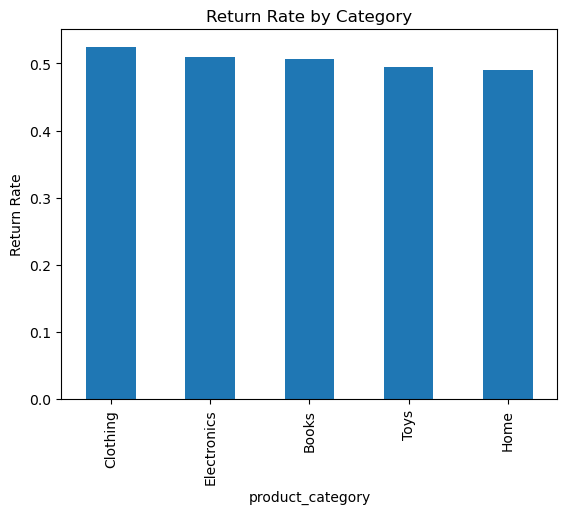

In [4]:
# Create binary return flag
df["return_flag"] = df["return_status"].map({"Returned": 1, "Not Returned": 0})

# Calculate return rate by category
category_return = df.groupby("product_category")["return_flag"].mean().sort_values(ascending=False)

# Plot
category_return.plot(kind="bar")
plt.title("Return Rate by Category")
plt.ylabel("Return Rate")
plt.show()

**Outcome** :
*The graph shows the return rate by category.*

> All categories have relatively high return rates, with Clothing, Electronics, Books, Toys, and Home each around 0.50 to 0.54 return rate. This suggests a consistently high tendency to return across product categories.

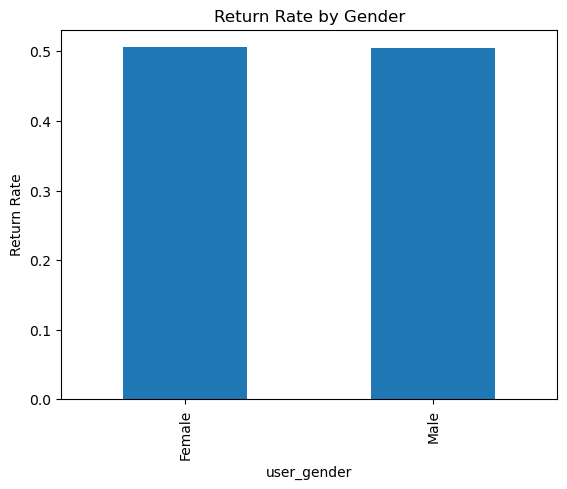

In [5]:
gender_return = df.groupby("user_gender")["return_flag"].mean()

gender_return.plot(kind="bar")
plt.title("Return Rate by Gender")
plt.ylabel("Return Rate")
plt.show()

**Outcome** : 
*The graph shows the return rate by gender.* 
> Both Female and Male have similar return rates, around 0.51 to 0.52. This suggests there is no substantial difference in return behavior between genders. 

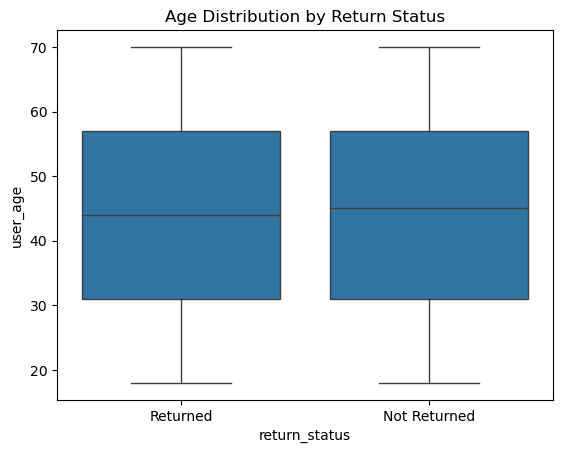

In [6]:
#Age v/s Return (are younger customers returning more?)

sns.boxplot(x="return_status", y="user_age", data=df)
plt.title("Age Distribution by Return Status")
plt.show()

**Outcome** : 
The graph shows the age distribution by return status. 

> Both Returned and Not Returned groups have similar age ranges, with medians around mid-40s and ages spanning roughly from the high 20s to mid-60s. This suggests no strong difference in age distribution between items that were returned and those that were not.

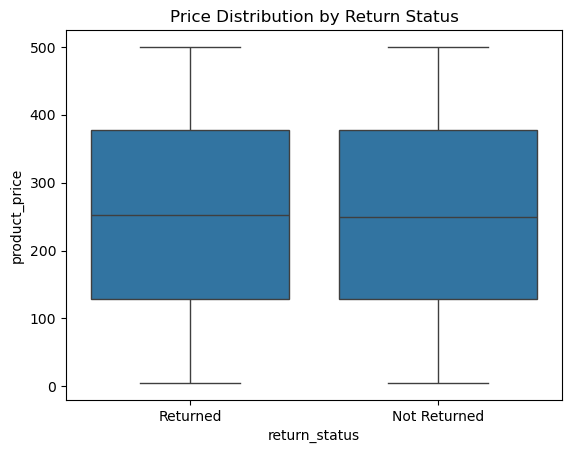

In [7]:
#Price vs Return (Are expensive products returned more?)

sns.boxplot(x="return_status", y="product_price", data=df)
plt.title("Price Distribution by Return Status")
plt.show()

**Outcome** : 
*The graph shows the price distribution by return status.*

> Both Returned and Not Returned groups have similar price ranges, with prices spanning from near 0 up to about 500.
> The median and quartiles appear close between the two groups, suggesting no strong difference in price distribution between items that were returned and those that were not.

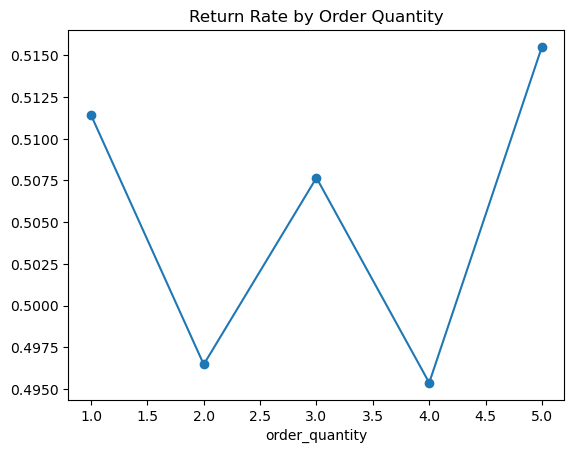

In [8]:
#Quantity Impact (Do bulk orders return more?)
quantity_return = df.groupby("order_quantity")["return_flag"].mean()

quantity_return.plot(marker='o')
plt.title("Return Rate by Order Quantity")
plt.show()

**Outcome** : 
*The graph shows the return rate by order quantity.*

> The return rate varies slightly with order quantity, fluctuating around 0.495–0.515.
> There is no strong monotonic trend; the rate moves up and down across quantities 1–5.

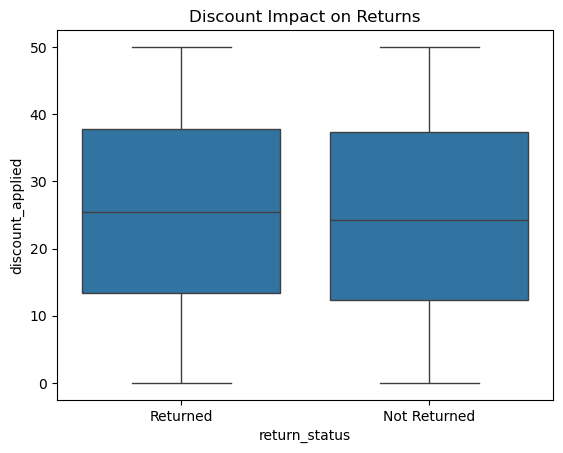

In [9]:
#Discount Impact (Higher discount → higher return?)

sns.boxplot(x="return_status", y="discount_applied", data=df)
plt.title("Discount Impact on Returns")
plt.show()

**Outcome** : 
*The graph shows the discount impact on returns*
    
> The box plots for Returned and Not Returned look fairly similar, indicating that applying the discount does not produce a large difference in the amount discounted between items that were returned and those that were not.
> Key statistics (medians, quartiles) appear close between the two groups, with discounts spanning roughly from near 0 up to about 50.

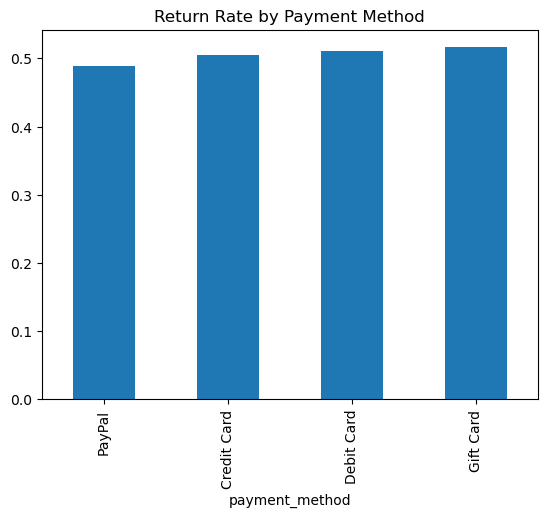

In [10]:
#Payment Method Impact (Does COD have higher returns?)
payment_return = df.groupby("payment_method")["return_flag"].mean().sort_values()

payment_return.plot(kind="bar")
plt.title("Return Rate by Payment Method")
plt.show()

**Outcome** : 
*The graph shows the return rate by payment method.*

> All payment methods have very similar return rates, around 0.49 to 0.51.
> There is no clear winner; the difference between methods is minimal.

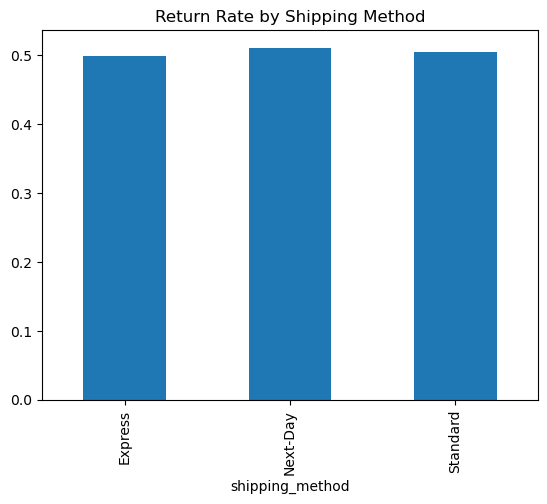

In [11]:
#Shipping Method Impact
shipping_return = df.groupby("shipping_method")["return_flag"].mean()

shipping_return.plot(kind="bar")
plt.title("Return Rate by Shipping Method")
plt.show()

**Outcome** : 
*The graph shows return rate by shipping method*
    
> All three methods (Express, Next-Day, Standard) have very similar return rates, around 0.49 to 0.51.
There is no clear difference in returns between the shipping options based on this plot.

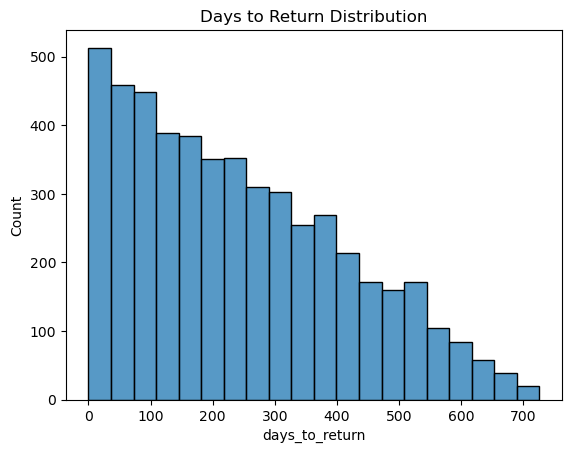

In [12]:
# how quickly are items returned?

sns.histplot(df[df["return_flag"] == 1]["days_to_return"], bins=20)
plt.title("Days to Return Distribution")
plt.show()

**Outcome** : 
*The chart shows the days-to-return distribution.*

> The counts are highest at very early days (1–20 days) and steadily decrease as days increase.
There appears to be a long tail up to around 700 days, but the bulk of returns occur within the first 100–200 days.
The distribution suggests most returns happen relatively soon after purchase, with fewer returns as time passes.

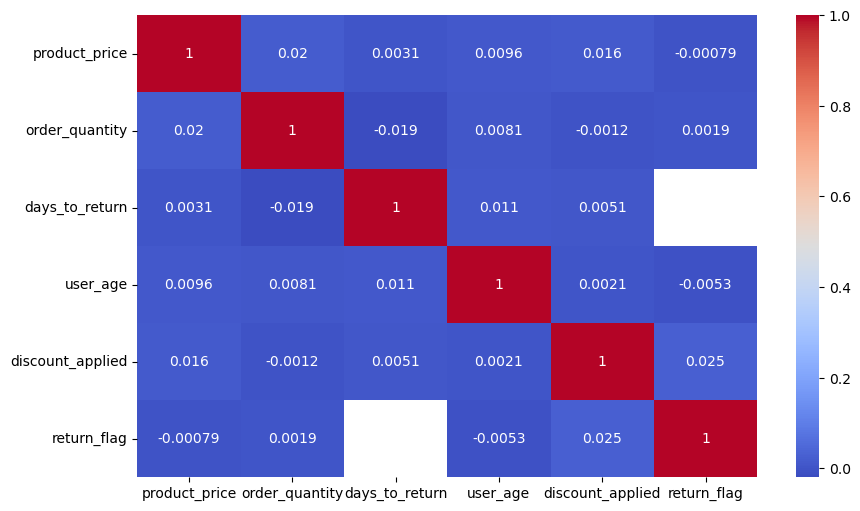

In [13]:
# heat map for ML model 
df["return_flag"] = df["return_status"].map({"Returned":1, "Not Returned":0})

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

**Outcome** : 

> There is no strong linear relationship among the six variables based on this correlation matrix.
If you are looking for predictive signals, these features alone may offer limited predictive power via linear associations; nonlinear relationships or interactions might be more informative.